In [ ]:
import torch 
from torch import nn
import matplotlib.pyplot as plt
torch.__version__

In [ ]:
weight=0.5
bias=0.2
start=0
end=1
step=0.02
X=torch.arange(start,end,step).unsqueeze(dim=1)
y=weight*X +bias
train_split=int(0.8*len(X))
# train_split
X

In [4]:
X_train,y_train=X[:train_split],y[:train_split]
X_test,y_test=X[train_split:],y[train_split:]

In [5]:
len(X_train),len(y_train),len(y_test)

(40, 40, 10)

In [6]:
"""
Plotting a graph for visualization
"""
def plot_pred(train_data=X_train,
             train_label=y_train,
             test_data=X_test,
             test_label=y_test,
             predictions=None):
    plt.figure(figsize=(10,7))
    plt.scatter(train_data,train_label,c="b")
    plt.scatter(test_data,test_label,c="g")
    if predictions is not None:
        plt.scatter(test_data,predictions,c="r")
    plt.legend(prop={"size": 14});

C:\Users\Darsh\AppData\Local\Temp\ipykernel_11632\2038289084.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(prop={"size": 14});


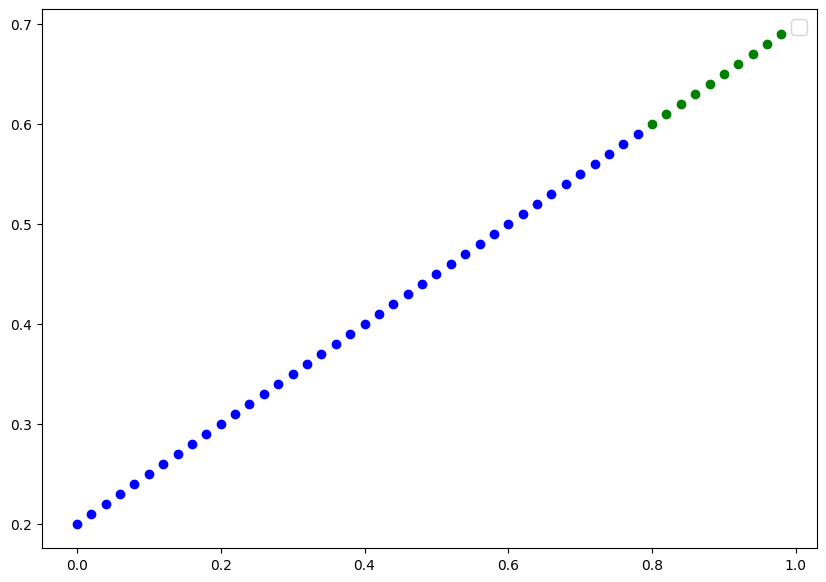

In [7]:
plot_pred()

In [14]:
#Building basic linear regression model in pytorch 

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        # self.weights=nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float32))
        # self.bias=nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float32))
        self.linear_layer=nn.Linear(in_features=1,out_features=1)
    def forward(self,x:torch.tensor)->torch.Tensor:
        # return self.weights*x+self.bias
        return self.linear_layer(x)

In [15]:
torch.manual_seed(42) # with random seed we can ensure that every time random initiate of weight,size parameter stays constant
model_0=LinearRegressionModel()
# list(model_0.parameters())
model_0.state_dict()
# model_0.linear_layer.weight


OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

In [16]:
with torch.inference_mode():  #when we just wanna check prediction and we dont want gradient descent and back prop we use this
    y_preds=model_0(X_test)
y_preds

tensor([[1.4416],
        [1.4569],
        [1.4722],
        [1.4875],
        [1.5028],
        [1.5181],
        [1.5334],
        [1.5487],
        [1.5640],
        [1.5793]])

C:\Users\Darsh\AppData\Local\Temp\ipykernel_11632\2038289084.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(prop={"size": 14});


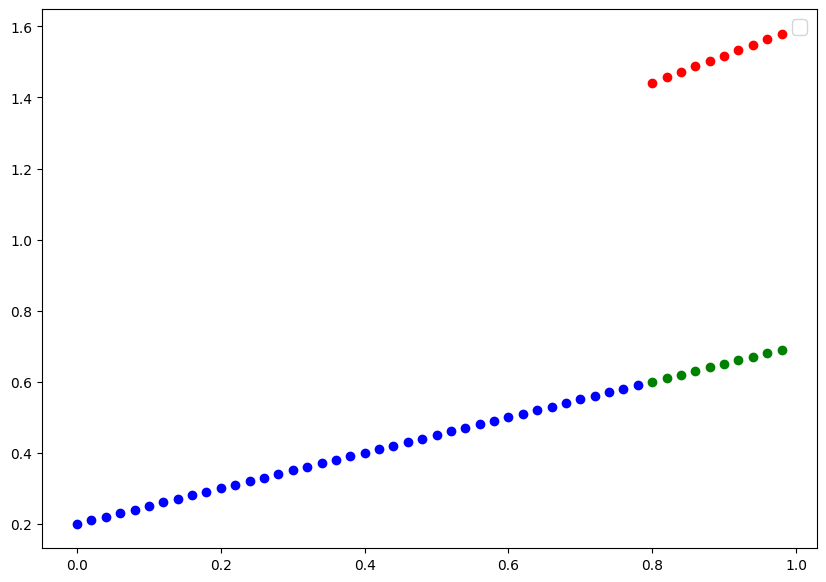

In [17]:
plot_pred(predictions=y_preds)

In [18]:
loss_fn=nn.L1Loss()
#loss function measures loss between predicted and actuall value 

In [19]:
loss_fn

L1Loss()

In [20]:
optimizer=torch.optim.SGD(params=model_0.parameters(),lr=0.01)
#optimizer try to modify parameters such as weight and bias to reduce the loss we hve SGD is stochastic gradient descent is
#optimizer/works like gradient descent it try to reduce the loss by balancing weight and 
#lr is how drastically we wanna change our parameters and its also comes under hyperperameter


In [21]:
torch.manual_seed(42)
epochs=100
epoch_count=[]
loss_count=[]
test_loss=[]
for epoch in range(epochs):
    model_0.train()

    y_pred=model_0(X_train)
    
    loss=loss_fn(y_pred,y_train)
    
    optimizer.zero_grad()

    loss.backward()
    print(f"loss before optimizer step{loss}")
    print(model_0.state_dict())
    optimizer.step() # it updates parameters and trys to move it forward or near to our answer 
    optimizer.step()

# recompute loss
    y_pred_new = model_0(X_train)
    new_loss = loss_fn(y_pred_new, y_train)
    print(f"loss after optimizer step {new_loss}")
    print(model_0.state_dict())
    with torch.no_grad():
        test_pred=model_0(X_test)
        test_loss=loss_fn(test_pred,y_test)
    if epoch%10==0:
        print(f"Epoch: {epoch} | Loss : {loss}| test loss:{test_loss}")
        print(model_0.state_dict())
    

loss before optimizer step0.7331780195236206
OrderedDict([('linear_layer.weight', tensor([[0.7645]])), ('linear_layer.bias', tensor([0.8300]))])
loss after optimizer step 0.7101359367370605
OrderedDict([('linear_layer.weight', tensor([[0.7567]])), ('linear_layer.bias', tensor([0.8100]))])
Epoch: 0 | Loss : 0.7331780195236206| test loss:0.8385052680969238
OrderedDict([('linear_layer.weight', tensor([[0.7567]])), ('linear_layer.bias', tensor([0.8100]))])
loss before optimizer step0.7101359367370605
OrderedDict([('linear_layer.weight', tensor([[0.7567]])), ('linear_layer.bias', tensor([0.8100]))])
loss after optimizer step 0.6870939135551453
OrderedDict([('linear_layer.weight', tensor([[0.7489]])), ('linear_layer.bias', tensor([0.7900]))])
loss before optimizer step0.6870939135551453
OrderedDict([('linear_layer.weight', tensor([[0.7489]])), ('linear_layer.bias', tensor([0.7900]))])
loss after optimizer step 0.6640520095825195
OrderedDict([('linear_layer.weight', tensor([[0.7411]])), ('lin

C:\Users\Darsh\AppData\Local\Temp\ipykernel_11632\2038289084.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(prop={"size": 14});


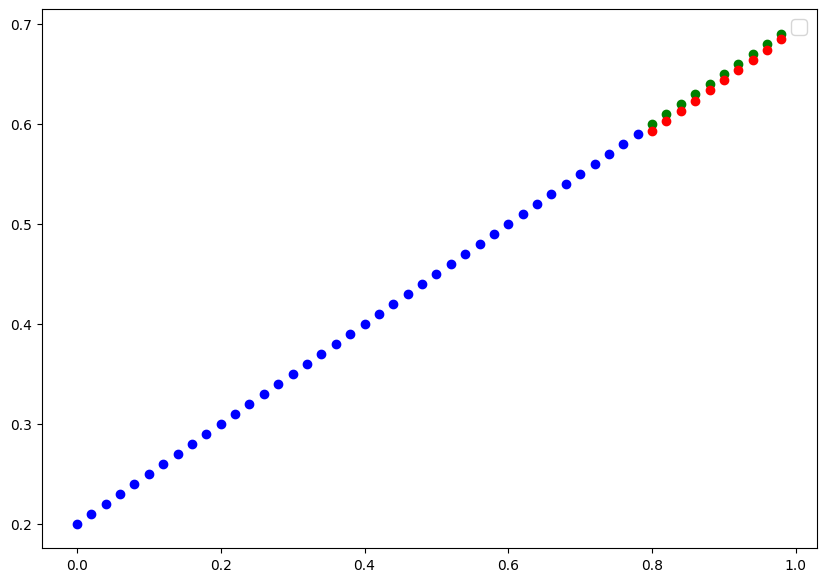

In [22]:
with torch.inference_mode():
    y_preds_new=model_0(X_test)
plot_pred(predictions=y_preds_new)

In [23]:
weight,bias

(0.5, 0.2)